### Implementation Details

In this section, we use the normal distribution to generate two sets of data to verify the asymptotic behavior of the KS statistic.

First, we consider the case of identical distributions, where both datasets are generated from a standard normal distribution $N(0,1)$. Theory suggests that the expected KS statistic should converge to 0 at a rate of approximately $1/\sqrt{n}$. Therefore, on a log-log plot, we expect to observe a line that is parallel to the theoretical convergence rate and trends downward to 0.

Second, to provide a comparison, we compare the case of different distributions by generating one dataset from $N(0,1)$ and the other from $N(1,1)$. The KS statistic is expected to be bounded away from 0. Therefore, we expect the plotted line remain at a non-zero value rather than converge to 0 as the $n$ increases.

In [16]:
using Plots
using Random 
include("C:/Users/Odysseus/GR6104_Homework/HW2/src/ks-stat.jl")

ks_func

In [17]:
num_of_ite = [10,50,100,500,2500,5000,12500]
Random.seed!(2026)
num_trials = 100

ks_same_dist = Float64[]
ks_diff_dist =Float64[]

for n in num_of_ite
    total_same = 0
    for _ in 1:num_trials 
        x = randn(n)
        y = randn(n)
        similar_val = ks_func(x,y)
        total_same +=similar_val
    end
    push!(ks_same_dist, total_same/num_trials)

    total_diff = 0
    for _ in 1:num_trials 
        x = randn(n)
        y = randn(n).+1.0
        diff_val = ks_func(x,y)
        total_diff +=diff_val
    end
    push!(ks_diff_dist, total_diff/num_trials)
end


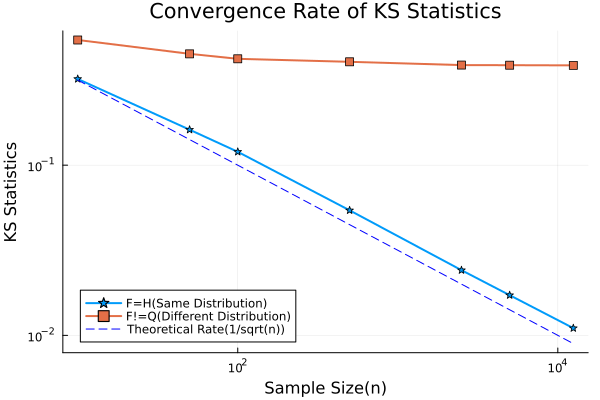

In [18]:
p = plot(num_of_ite, ks_same_dist,
    label = "F=H(Same Distribution)",
    xlabel = "Sample Size(n)",
    ylabel = "KS Statistics",
    title = "Convergence Rate of KS Statistics",
    lw = 2, marker =:star,
    xaxis=:log, yaxis=:log,
    legend =:bottomleft
)

plot!(p,num_of_ite,ks_diff_dist,
    label ="F!=Q(Different Distribution)",
    lw = 2,marker =:square
    )

theoretical_rate = 1.0 ./sqrt.(num_of_ite)
plot!(p,num_of_ite,theoretical_rate,
    label ="Theoretical Rate(1/sqrt(n))",
    linestyle=:dash, color=:blue
    )
display(p)

The log-log plot shows a clear linear relationship with a slope of approximately $-0.5$. 
This confirms that the empirical convergence rate of the two-same-sample KS statistic is indeed $O(1/\sqrt{n})$.

We have evidence to show that we implemented the KS statistic correctly.